# ETAPA 02 - Análise Exploratória de Dados (EDA) M2

## Projeto: Manutenção Preditiva de "Zero-Downtime"

**Disciplina:** Ciência de Dados  
**Curso:** Engenharia de Controle e Automação  
**Grupo:** E  

### Integrantes
- Bruno Alves Guedes
- Guilherme Nascimento
- Guilherme Fernando
- Lucas Guedes
- Pedro Henrique Mateus

### Dataset utilizado
**AI4I 2020 Predictive Maintenance Dataset**

## 1. Objetivo da Análise

Este notebook tem como objetivo realizar a Análise Exploratória de Dados (EDA) do dataset **AI4I 2020 Predictive Maintenance Dataset**, buscando compreender a estrutura da base, identificar padrões, correlações, possíveis outliers e levantar hipóteses relevantes para a etapa de modelagem preditiva.

A análise está inserida no contexto de **manutenção preditiva industrial**, com foco na antecipação de falhas em equipamentos para redução de downtime não planejado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

## 2. Carregamento dos Dados

Nesta etapa, carregamos o dataset tratado na M1 para iniciar a análise exploratória.

In [2]:
df = pd.read_csv("../data/processed/dados_tratados.csv")
df.head()

,udi,product_id,type,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Visão Geral do Dataset

Aqui verificamos a dimensão da base, os tipos das variáveis, presença de valores nulos e estatísticas descritivas iniciais.

In [3]:
print("Dimensão do dataset:", df.shape)

Dimensão do dataset: (10000, 14)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   product_id               10000 non-null  object 
 2   type                     10000 non-null  object 
 3   air_temperature_[k]      10000 non-null  float64
 4   process_temperature_[k]  10000 non-null  float64
 5   rotational_speed_[rpm]   10000 non-null  int64  
 6   torque_[nm]              10000 non-null  float64
 7   tool_wear_[min]          10000 non-null  int64  
 8   machine_failure          10000 non-null  int64  
 9   twf                      10000 non-null  int64  
 10  hdf                      10000 non-null  int64  
 11  pwf                      10000 non-null  int64  
 12  osf                      10000 non-null  int64  
 13  rnf                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,udi,air_temperature_[k],process_temperature_[k],rotational_speed_[rpm],torque_[nm],tool_wear_[min],machine_failure,twf,hdf,pwf,osf,rnf
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.isnull().sum()

udi                        0
product_id                 0
type                       0
air_temperature_[k]        0
process_temperature_[k]    0
rotational_speed_[rpm]     0
torque_[nm]                0
tool_wear_[min]            0
machine_failure            0
twf                        0
hdf                        0
pwf                        0
osf                        0
rnf                        0
dtype: int64

## 4. Descrição das Variáveis

As principais variáveis do dataset são:

- `udi`: identificador único do registro
- `product_id`: identificador do produto
- `type`: tipo do produto
- `air_temperature_[k]`: temperatura do ar
- `process_temperature_[k]`: temperatura do processo
- `rotational_speed_[rpm]`: velocidade rotacional
- `torque_[nm]`: torque
- `tool_wear_[min]`: desgaste da ferramenta
- `machine_failure`: indicação de falha geral da máquina
- `twf`, `hdf`, `pwf`, `osf`, `rnf`: tipos específicos de falha

## 5. Verificação de Consistência

Nesta etapa verificamos duplicidades e possíveis inconsistências estruturais nos dados.

In [7]:
print("Quantidade de duplicatas:", df.duplicated().sum())

Quantidade de duplicatas: 0


In [8]:
df.nunique()

udi                        10000
product_id                 10000
type                           3
air_temperature_[k]           93
process_temperature_[k]       82
rotational_speed_[rpm]       941
torque_[nm]                  577
tool_wear_[min]              246
machine_failure                2
twf                            2
hdf                            2
pwf                            2
osf                            2
rnf                            2
dtype: int64

## 6. Distribuição da Variável Alvo

A variável `machine_failure` representa a ocorrência ou não de falha da máquina. Sua distribuição é importante para entender o equilíbrio da base.

In [9]:
df["machine_failure"].value_counts()

machine_failure
0    9661
1     339
Name: count, dtype: int64

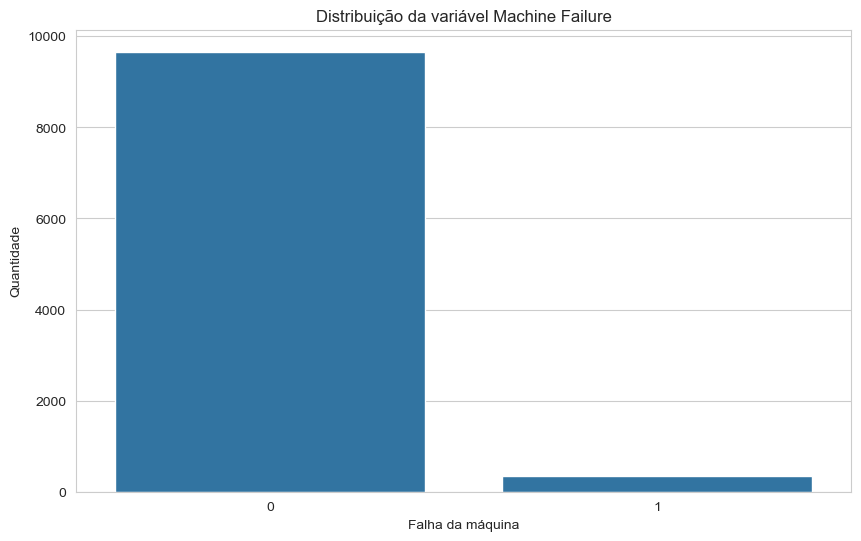

In [10]:
sns.countplot(data=df, x="machine_failure")
plt.title("Distribuição da variável Machine Failure")
plt.xlabel("Falha da máquina")
plt.ylabel("Quantidade")
plt.show()

### Análise

Observa-se a distribuição entre registros com falha e sem falha, permitindo avaliar se a base apresenta desbalanceamento, aspecto importante para futuras etapas de modelagem preditiva.

## 7. Análise das Variáveis Categóricas

Nesta seção analisamos a variável categórica `type`, verificando sua distribuição e possível relação com falhas.

In [11]:
df["type"].value_counts()

type
L    6000
M    2997
H    1003
Name: count, dtype: int64

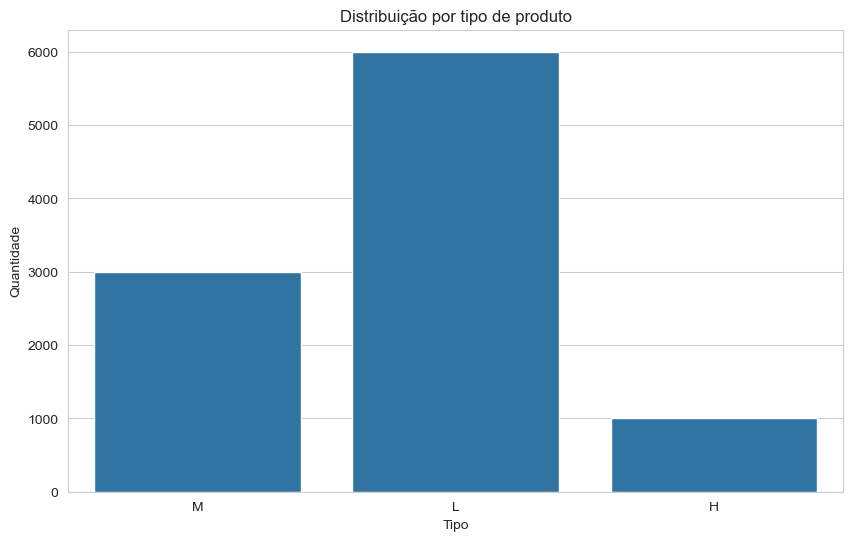

In [12]:
sns.countplot(data=df, x="type")
plt.title("Distribuição por tipo de produto")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.show()

In [13]:
pd.crosstab(df["type"], df["machine_failure"], normalize="index") * 100

machine_failure,0,1
type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


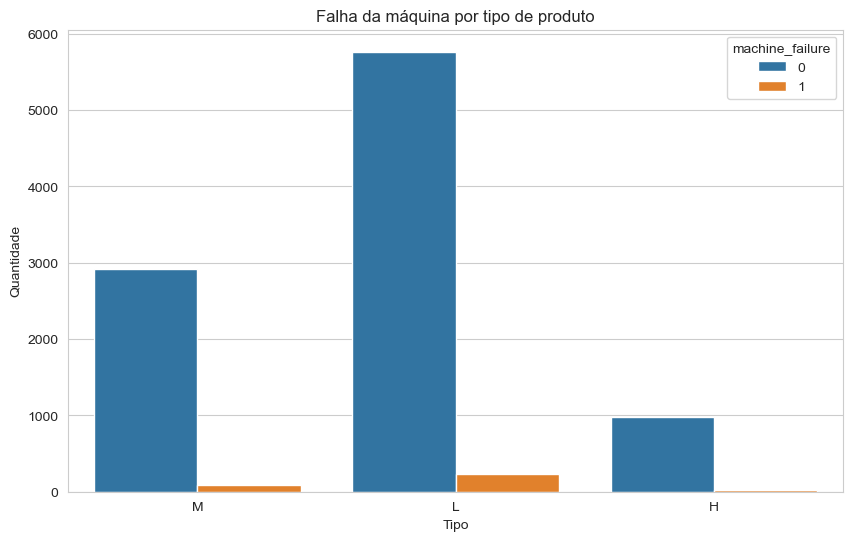

In [14]:
sns.countplot(data=df, x="type", hue="machine_failure")
plt.title("Falha da máquina por tipo de produto")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.show()

## 8. Análise Univariada das Variáveis Numéricas

Nesta etapa observamos a distribuição individual das principais variáveis numéricas do dataset.

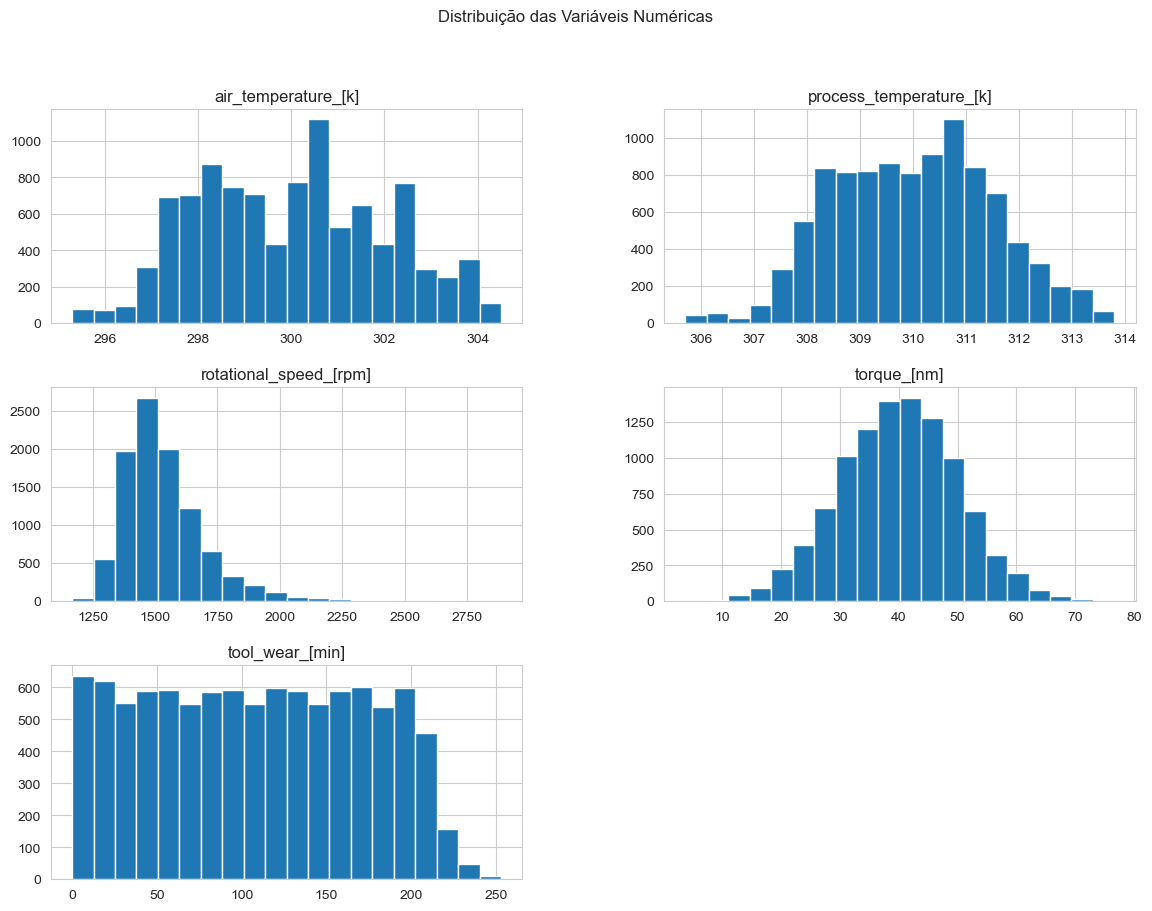

In [15]:
numeric_cols = [
    "air_temperature_[k]",
    "process_temperature_[k]",
    "rotational_speed_[rpm]",
    "torque_[nm]",
    "tool_wear_[min]"
]

df[numeric_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribuição das Variáveis Numéricas")
plt.show()

## 9. Identificação de Outliers

Os boxplots ajudam a visualizar valores extremos nas variáveis numéricas, o que pode indicar comportamentos anormais ou padrões relevantes para a manutenção preditiva.

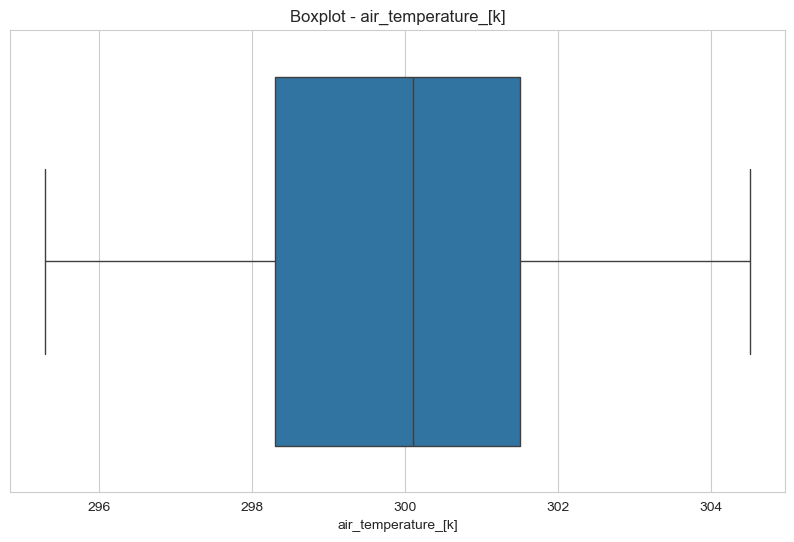

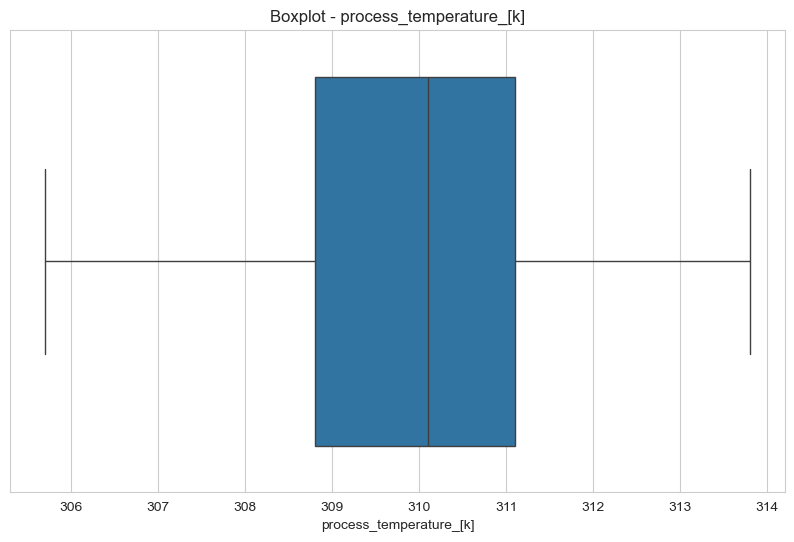

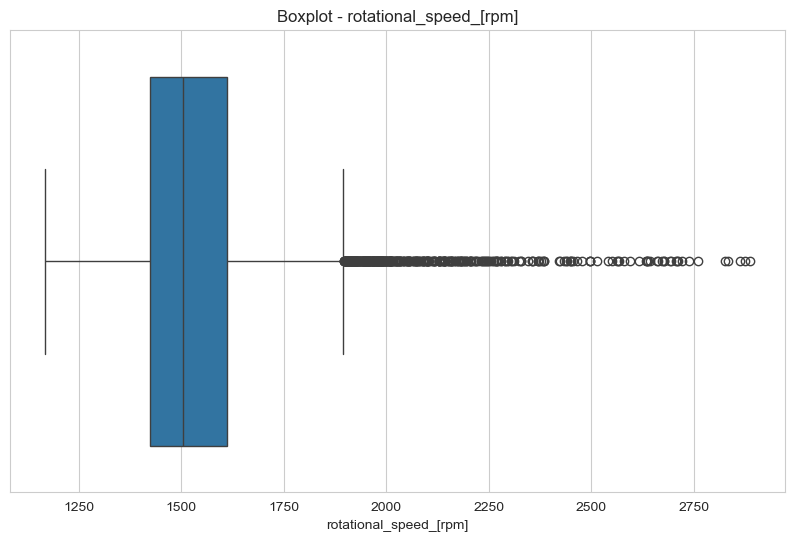

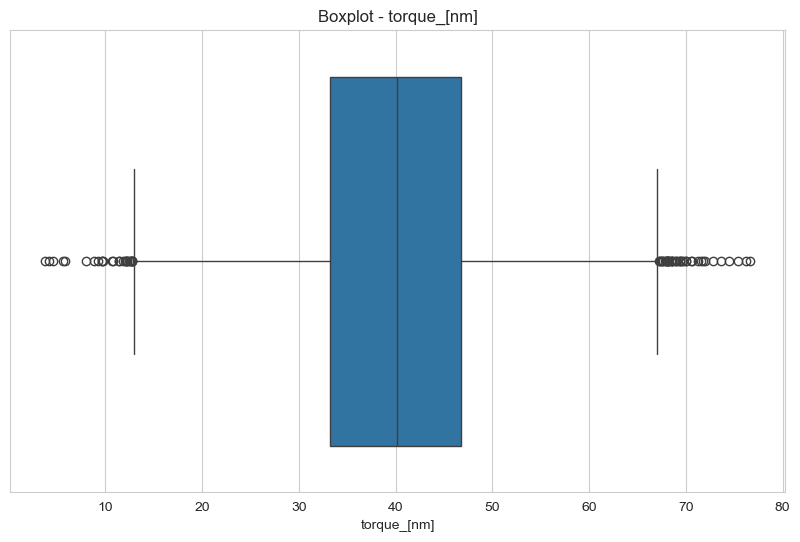

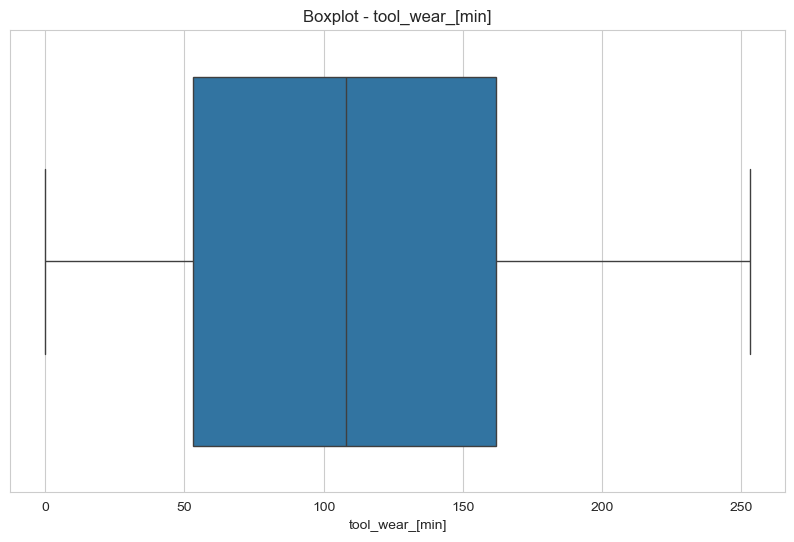

In [16]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

### Análise

Os boxplots permitem observar a presença de possíveis outliers, especialmente em variáveis operacionais como velocidade rotacional, torque e desgaste da ferramenta.

## 10. Correlação entre Variáveis

A matriz de correlação permite verificar relações lineares entre as variáveis numéricas, auxiliando na identificação de padrões relevantes para a ocorrência de falhas.

In [17]:
corr = df[numeric_cols + ["machine_failure"]].corr()
corr["machine_failure"].sort_values(ascending=False)

machine_failure            1.000000
torque_[nm]                0.191321
tool_wear_[min]            0.105448
air_temperature_[k]        0.082556
process_temperature_[k]    0.035946
rotational_speed_[rpm]    -0.044188
Name: machine_failure, dtype: float64

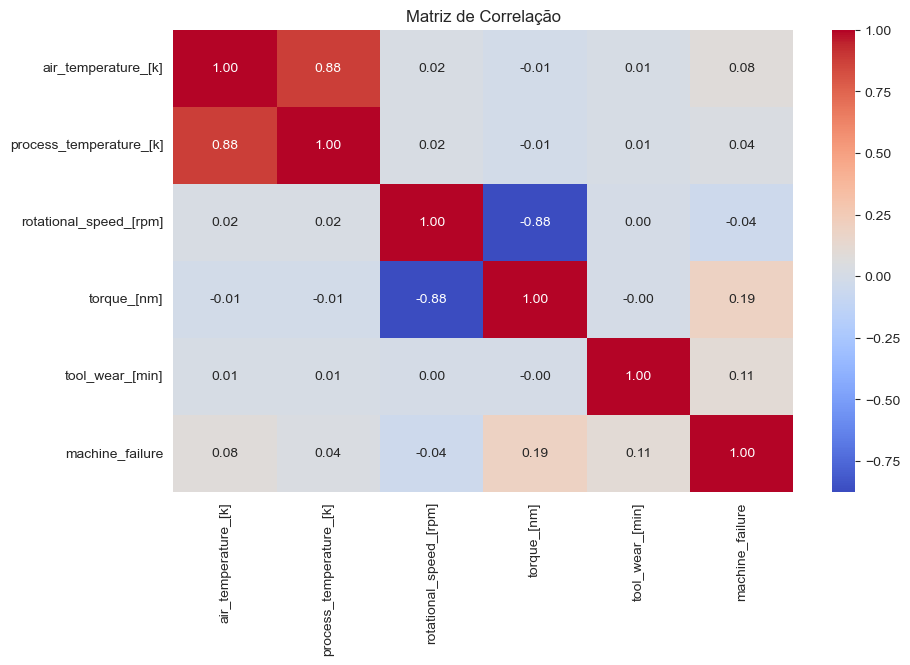

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

### Análise

A matriz de correlação permite avaliar quais variáveis apresentam maior associação com a variável de falha da máquina, além de verificar relações entre os próprios atributos operacionais.

## 11. Gráfico Analítico 1: Torque vs Desgaste da Ferramenta

Este gráfico busca verificar se há concentração de falhas em regiões específicas de torque e desgaste da ferramenta.

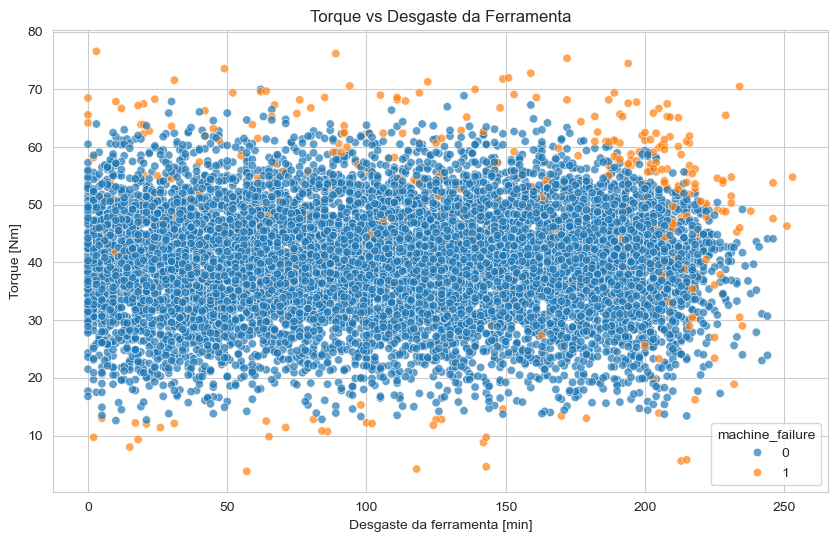

In [19]:
sns.scatterplot(
    data=df,
    x="tool_wear_[min]",
    y="torque_[nm]",
    hue="machine_failure",
    alpha=0.7
)
plt.title("Torque vs Desgaste da Ferramenta")
plt.xlabel("Desgaste da ferramenta [min]")
plt.ylabel("Torque [Nm]")
plt.show()

## 12. Gráfico Analítico 2: Velocidade Rotacional por Ocorrência de Falha

Este gráfico compara a distribuição da velocidade rotacional entre máquinas com e sem falha.

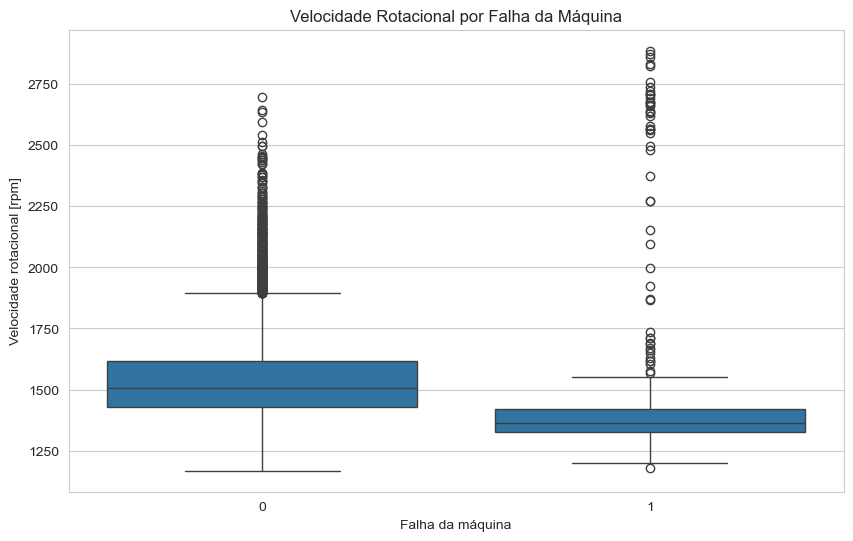

In [20]:
sns.boxplot(data=df, x="machine_failure", y="rotational_speed_[rpm]")
plt.title("Velocidade Rotacional por Falha da Máquina")
plt.xlabel("Falha da máquina")
plt.ylabel("Velocidade rotacional [rpm]")
plt.show()

## 13. Gráfico Analítico 3: Temperatura de Processo por Ocorrência de Falha

Este gráfico avalia se a temperatura de processo apresenta comportamento distinto entre registros com falha e sem falha.

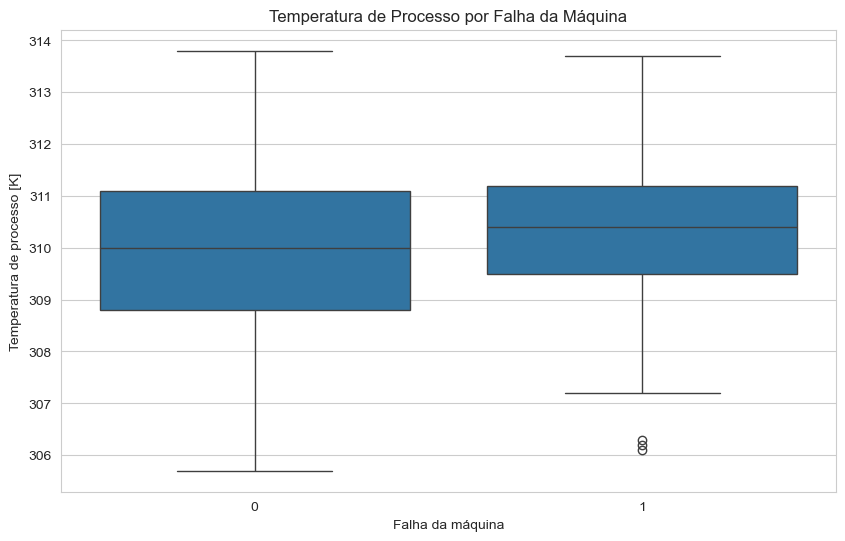

In [21]:
sns.boxplot(data=df, x="machine_failure", y="process_temperature_[k]")
plt.title("Temperatura de Processo por Falha da Máquina")
plt.xlabel("Falha da máquina")
plt.ylabel("Temperatura de processo [K]")
plt.show()

## 14. Levantamento de Hipóteses

Com base na análise exploratória, foram levantadas as seguintes hipóteses:

1. Maiores valores de desgaste da ferramenta estão associados a maior probabilidade de falha.
2. Alterações na velocidade rotacional podem estar relacionadas à ocorrência de falha.
3. Temperaturas mais elevadas no processo podem contribuir para comportamentos anormais da máquina.
4. O torque pode apresentar padrão distinto em registros com falha.

## 15. Validação Inicial das Hipóteses

A validação inicial foi realizada de forma exploratória, por meio de:
- comparação visual entre distribuições;
- análise de boxplots;
- inspeção da matriz de correlação;
- observação de padrões em gráficos de dispersão.

As evidências observadas nesta etapa servirão como base para testes mais robustos e para a futura modelagem preditiva.

## 16. Principais Achados da EDA

A análise exploratória permitiu identificar:

- a estrutura geral e a qualidade do dataset;
- a distribuição da variável alvo;
- possíveis outliers em variáveis operacionais;
- padrões visuais entre desgaste, torque, rotação e falha;
- relações relevantes entre variáveis numéricas e ocorrência de falha.

Esses resultados indicam que o dataset é adequado para as próximas etapas de modelagem.

## 17. Conclusão

A EDA permitiu compreender melhor o comportamento das variáveis do dataset de manutenção preditiva, identificar padrões relevantes e levantar hipóteses iniciais sobre os fatores relacionados à falha da máquina.

Como próximos passos, o grupo pretende aprofundar o tratamento dos dados, selecionar atributos mais relevantes e iniciar a etapa de modelagem preditiva.

## Apêndice de IA

A ferramenta de IA foi utilizada como apoio em atividades de:
- organização da estrutura do notebook;
- revisão de código Python;
- sugestões de visualizações e hipóteses analíticas;
- apoio textual na documentação.

Toda interpretação dos resultados, validação das análises e conferência dos gráficos foi realizada manualmente pelo grupo.